<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-II/blob/main/Grafos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 align="center">
<font color="#8E3B46">Caminata aleatoria sobre un grafo</font>
</h1>

**Nombre:** Michelle

---

<h2>
<font color="#B05A67">Instrucciones</font>
</h2>

Elabore en un cuaderno de Jupyter Notebook en lenguaje Python el código de la **caminata aleatoria sobre un grafo** para estimar el **número esperado de 1's en una buena cadena**, visto en clase.

<h2>
<font color="#B05A67">Planteamiento del problema</font>
</h2>

Consideremos una cadena binaria de longitud $m$, formada por 0's y 1's. Una cadena se considera **buena** si no contiene dos 1's adyacentes.

Por ejemplo, para $m=3$:

- $(011)$ no es una buena cadena, porque contiene dos 1's consecutivos.
- $(100)$ es una buena cadena.
- $(000)$ también es una buena cadena.

El problema consiste en determinar el **número esperado de 1's en una buena cadena**, considerando que todas las buenas cadenas de longitud $m$ tienen la misma probabilidad.

<h3>
<font color="#B05A67">Ejemplo para $m=4$</font>
</h3>

Para $m=4$ existen 8 buenas cadenas:

$$
(0000),\ (1000),\ (0100),\ (0010),
$$

$$
(0001),\ (1010),\ (1001),\ (0101).
$$

Como todas tienen la misma probabilidad, podemos calcular el número esperado de 1's contando cuántos contiene cada cadena y obteniendo su promedio:

$$
\begin{aligned}
\mu
&=\frac{0+1+1+1+1+2+2+2}{8}=\frac{10}{8}
=1.25.
\end{aligned}
$$

Por lo tanto, para $m=4$, el número esperado de 1's en una buena cadena es

$$
\boxed{\mu=1.25}.
$$

<h3>
<font color="#B05A67">Dificultad para generar buenas cadenas</font>
</h3>

Para $m=4$ fue posible identificar todas las buenas cadenas y calcular directamente el número esperado de 1's. Sin embargo, cuando aumenta la longitud de la cadena, este procedimiento se vuelve más complicado.

Una alternativa sería generar cadenas binarias al azar y conservar únicamente aquellas que sean buenas. No obstante, para $m=100$ existen aproximadamente

$$
2^{100}\approx 10^{30}
$$

cadenas binarias, de las cuales alrededor de $10^{21}$ son buenas.

Por lo tanto, la proporción de buenas cadenas es aproximadamente

$$
\frac{10^{21}}{10^{30}}=10^{-9}.
$$

Esto significa que, en promedio, sería necesario generar alrededor de mil millones de cadenas binarias para obtener una buena.

Debido a esta dificultad, utilizaremos una **cadena de Markov construida mediante una caminata aleatoria sobre un grafo**, que nos permitirá generar buenas cadenas sin tener que buscar entre todas las posibles secuencias binarias.

<h3>
<font color="#B05A67">Caso general</font>
</h3>

Para una cadena de longitud $m$, sea $\pi_k$ la probabilidad de que una buena cadena tenga exactamente $k$ 1's.

Entonces, el número esperado de 1's está dado por

$$
\mu=\sum_k k\pi_k.
$$

Si $x$ es una cadena binaria de longitud $m$, definimos

$$
r(x)=\text{número de 1's en la cadena }x.
$$

Por lo tanto, nuestro objetivo es estimar el valor esperado de $r(x)$, considerando todas las buenas cadenas con la misma probabilidad.

<h2>
<font color="#B05A67">Caminata aleatoria sobre un grafo</font>
</h2>

Para estimar $\mu$, construiremos una cadena de Markov ergódica

$$
X_0,X_1,X_2,\ldots
$$

cuyos estados serán todas las buenas cadenas de longitud $m$ y cuya distribución estacionaria será uniforme sobre ellas.

Esta cadena se construye mediante una **caminata aleatoria sobre un grafo**, donde:

- Cada buena cadena representa un **vértice**.
- Dos vértices se conectan mediante una **arista de peso 1** si sus cadenas difieren exactamente en una componente.
- Los **lazos** representan los casos en los que la caminata permanece en el mismo vértice porque el cambio propuesto produciría una cadena que no es buena.

El peso de cada lazo se elige de manera que el peso total de las conexiones de cada vértice sea $m$.

Como todos los vértices tienen el mismo peso total, la distribución estacionaria de la caminata es uniforme sobre las buenas cadenas.

<h3>
<font color="#B05A67">Regla de transición</font>
</h3>

A partir de una buena cadena $X_n$, se selecciona uniformemente al azar una de sus $m$ componentes.

- Si la componente seleccionada es 1, se cambia a 0 y la caminata pasa a la nueva buena cadena.
- Si la componente seleccionada es 0, se intenta cambiar a 1. El cambio se realiza únicamente si la nueva cadena sigue siendo buena.
- Si el cambio produce dos 1's adyacentes, la caminata permanece en el estado actual.

De esta manera se obtiene el siguiente estado $X_{n+1}$.

Para comprender esta construcción, primero representaremos el grafo correspondiente a $m=4$.

In [18]:
import networkx as nx
import matplotlib.pyplot as plt

# Buenas cadenas de longitud m = 4
m = 4

buenas = [
    "0000", "1000", "0100", "0010",
    "0001", "1010", "1001", "0101"
]

# Creamos el grafo y agregamos las buenas cadenas como vértices
G = nx.Graph()
G.add_nodes_from(buenas)

# Comparamos cada par de cadenas
for i in range(len(buenas)):
    for j in range(i + 1, len(buenas)):

        # Contamos en cuántas componentes son diferentes
        diferencias = sum(
            buenas[i][k] != buenas[j][k]
            for k in range(m)
        )

        # Si difieren en una sola componente, se unen con peso 1
        if diferencias == 1:
            G.add_edge(buenas[i], buenas[j], weight=1)

In [19]:
# Revisamos cada buena cadena
for X in buenas:

    # Contamos los cambios que no están permitidos
    lazos = 0

    for i in range(m):

        # Solo intentamos cambiar las componentes iguales a 0
        if X[i] == "0":

            X_nueva = list(X)
            X_nueva[i] = "1"
            X_nueva = "".join(X_nueva)

            # Si la cadena resultante no es buena,
            # la caminata permanece en el mismo vértice
            if X_nueva not in buenas:
                lazos += 1

    # Agregamos el lazo con el peso correspondiente
    if lazos > 0:
        G.add_edge(X, X, weight=lazos)

<h3>
<font color="#B05A67">Representación del grafo para $m=4$</font>
</h3>

El siguiente grafo muestra las 8 buenas cadenas de longitud $m=4$ y las conexiones que existen entre ellas.

Las aristas tienen peso 1, mientras que los lazos indican los movimientos que no están permitidos y su peso representa cuántas veces puede permanecer la caminata en el mismo vértice.

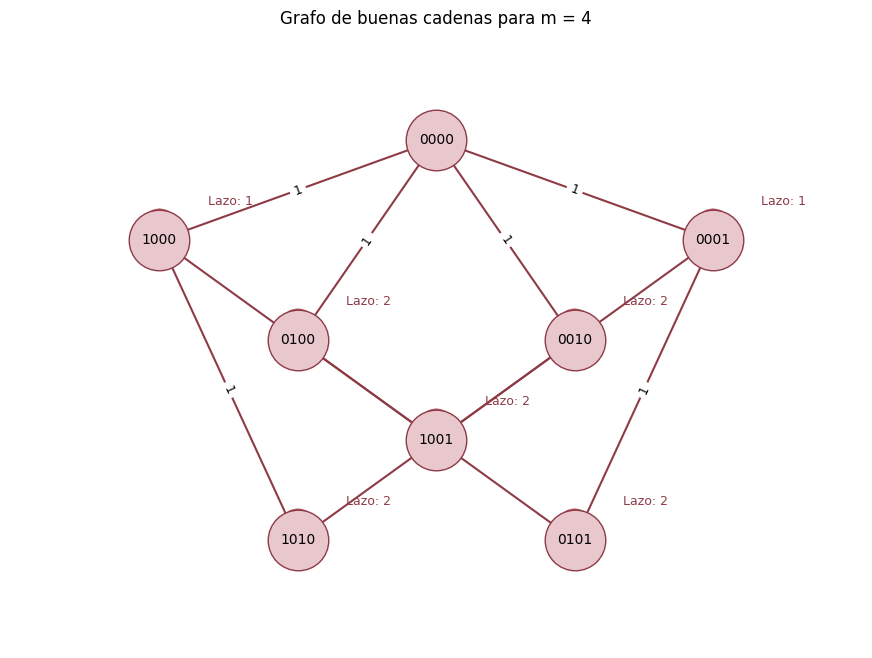

In [20]:
# Posiciones de los vértices para organizar el grafo
pos = {
    "0000": (0, 3),
    "1000": (-2, 2),
    "0100": (-1, 1),
    "0010": (1, 1),
    "0001": (2, 2),
    "1010": (-1, -1),
    "1001": (0, 0),
    "0101": (1, -1)
}

plt.figure(figsize=(11, 8))

# Dibujamos los vértices y sus etiquetas
nx.draw_networkx_nodes(
    G, pos,
    node_color="#E8C7CD",
    edgecolors="#8E3B46",
    node_size=1900
)

nx.draw_networkx_labels(
    G, pos,
    font_size=10
)

# Separamos las aristas de los lazos
aristas = [(u, v) for u, v in G.edges() if u != v]
lazos = [(u, v) for u, v in G.edges() if u == v]

# Dibujamos las aristas entre vértices diferentes
nx.draw_networkx_edges(
    G, pos,
    edgelist=aristas,
    edge_color="#8E3B46",
    width=1.5
)

# Dibujamos los lazos
nx.draw_networkx_edges(
    G, pos,
    edgelist=lazos,
    edge_color="#B05A67",
    width=2,
    node_size=1900
)

# Mostramos los pesos de las aristas
pesos = {
    (u, v): G[u][v]["weight"]
    for u, v in aristas
}

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=pesos,
    font_size=9
)

# Indicamos el peso de cada lazo junto a su vértice
for X in buenas:
    if G.has_edge(X, X):
        peso = G[X][X]["weight"]
        x, y = pos[X]

        plt.text(
            x + 0.35, y + 0.35,
            f"Lazo: {peso}",
            fontsize=9,
            color="#8E3B46"
        )

plt.title("Grafo de buenas cadenas para m = 4")
plt.axis("off")
plt.margins(0.2)
plt.show()

In [21]:
# Comprobamos el peso total de cada vértice
for X in buenas:

    # Sumamos los pesos de sus conexiones, incluido el lazo
    peso_total = sum(
        G[X][Y]["weight"]
        for Y in G.neighbors(X)
    )

    print(X, "-> Peso total:", peso_total)

0000 -> Peso total: 4
1000 -> Peso total: 4
0100 -> Peso total: 4
0010 -> Peso total: 4
0001 -> Peso total: 4
1010 -> Peso total: 4
1001 -> Peso total: 4
0101 -> Peso total: 4


<h3>
<font color="#B05A67">Observación</font>
</h3>

En el grafo podemos identificar las 8 buenas cadenas y los movimientos permitidos entre ellas. Las aristas representan cambios de una sola componente, mientras que los lazos corresponden a los cambios que producirían 1's adyacentes.

Por ejemplo, el vértice $(1001)$ tiene dos conexiones con otras buenas cadenas y un lazo de peso 2, por lo que su peso total es 4.

Al comprobar que todos los vértices tienen el mismo peso total $m=4$, se justifica que la distribución estacionaria de esta caminata sea uniforme sobre las buenas cadenas.

In [22]:
def buena_cadena(X):

    # Revisamos cada componente junto con la siguiente
    for i in range(len(X) - 1):

        # Si encontramos dos 1's consecutivos, no es buena
        if X[i] == 1 and X[i + 1] == 1:
            return False

    # Si no encontramos 1's consecutivos, la cadena es buena
    return True

In [23]:
import random

def caminata(X_n):

    # Obtenemos la longitud de la cadena
    m = len(X_n)

    # Elegimos al azar una de sus m componentes
    i = random.randrange(m)

    # Hacemos una copia para conservar la cadena actual
    X_nueva = X_n.copy()

    # Si la componente es 1, la cambiamos a 0
    if X_n[i] == 1:
        X_nueva[i] = 0

    # Si es 0, intentamos cambiarla a 1
    else:
        X_nueva[i] = 1

        # Si deja de ser buena, conservamos la cadena anterior
        if not buena_cadena(X_nueva):
            X_nueva = X_n.copy()

    # Devolvemos el siguiente estado de la caminata
    return X_nueva

In [24]:
# Comenzamos con una buena cadena de longitud m = 4
X_n = [0, 0, 0, 0]

print("Estado inicial:", X_n)

# Realizamos 10 pasos de la caminata
for j in range(1, 11):

    X_n = caminata(X_n)

    print(f"Paso {j}: {X_n}")

Estado inicial: [0, 0, 0, 0]
Paso 1: [0, 1, 0, 0]
Paso 2: [0, 0, 0, 0]
Paso 3: [0, 0, 1, 0]
Paso 4: [0, 0, 1, 0]
Paso 5: [1, 0, 1, 0]
Paso 6: [1, 0, 1, 0]
Paso 7: [0, 0, 1, 0]
Paso 8: [0, 0, 0, 0]
Paso 9: [0, 1, 0, 0]
Paso 10: [0, 0, 0, 0]


<h3>
<font color="#B05A67">Observación</font>
</h3>

La caminata genera una sucesión de buenas cadenas a partir de un estado inicial. En cada paso puede cambiar una componente o permanecer en el mismo estado, dependiendo de si el movimiento está permitido.

Aunque los resultados varían por la selección aleatoria, todas las cadenas generadas cumplen la condición de no tener dos 1's adyacentes.

<h2>
<font color="#B05A67">Estimación del número esperado de 1's</font>
</h2>

Como la cadena de Markov construida es ergódica y tiene una distribución estacionaria uniforme sobre las buenas cadenas, podemos aplicar la **Ley Fuerte de los Grandes Números para cadenas de Markov**:

$$
\lim_{n\to\infty}
\frac{1}{n}\sum_{j=1}^{n}r(X_j)
=
E[r(X)]
=
\mu,
\qquad \text{casi seguramente}.
$$

Recordemos que $r(X_j)$ representa el número de 1's en la cadena $X_j$.

Por lo tanto, después de realizar $n$ pasos de la caminata, podemos estimar el número esperado de 1's mediante

$$
\boxed{
\hat{\mu}=\frac{1}{n}\sum_{j=1}^{n}r(X_j)
}
$$

Es decir, calculamos el número de 1's de cada cadena generada y obtenemos su promedio.

<h3>
<font color="#B05A67">Simulación para $m=100$</font>
</h3>

Consideremos buenas cadenas de longitud $m=100$. Iniciaremos la caminata en la cadena formada únicamente por ceros:

$$
X_0=(0,0,\ldots,0).
$$

Realizaremos $n=100\,000$ pasos y, en cada uno, calcularemos $r(X_j)$ para estimar el número esperado de 1's.

En este caso no es necesario construir explícitamente el grafo, ya que podemos generar los movimientos mediante la función `caminata()`.

In [25]:
# Número de componentes y pasos de la caminata
m = 100
n = 100000

# Comenzamos con una cadena formada por m ceros
X_n = [0] * m

# Guardamos las estimaciones para observar su evolución
estimaciones = []

# Acumulamos el número de 1's de las cadenas generadas
suma_r = 0

for j in range(1, n + 1):

    # Avanzamos un paso en la caminata
    X_n = caminata(X_n)

    # Contamos los 1's del estado actual: r(X_j)
    r_X = sum(X_n)

    # Sumamos este valor a los anteriores
    suma_r += r_X

    # Calculamos el promedio hasta el paso j
    mu_j = suma_r / j
    estimaciones.append(mu_j)

# Estimación obtenida después de n pasos
mu = suma_r / n

print("Longitud de la cadena (m):", m)
print("Número de pasos (n):", n)
print(f"Estimación de mu: {mu:.4f}")

Longitud de la cadena (m): 100
Número de pasos (n): 100000
Estimación de mu: 27.9107


<h3>
<font color="#B05A67">Evolución de la estimación</font>
</h3>

Para observar el comportamiento de la caminata, representaremos el promedio acumulado de 1's conforme aumenta el número de pasos.

También incluiremos el valor de referencia $\mu\approx27.7921$, con el propósito de comparar la estimación obtenida mediante la simulación.

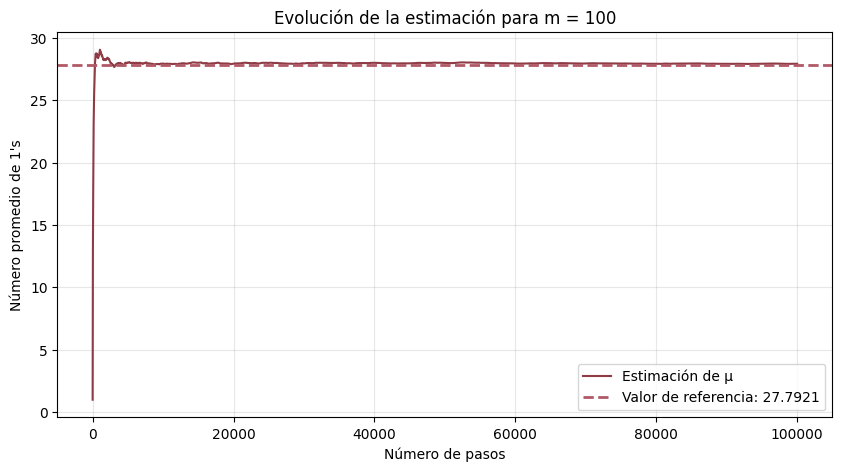

In [26]:
# Valor de referencia para m = 100
mu_referencia = 27.7921

plt.figure(figsize=(10, 5))

# Promedio acumulado obtenido en la simulación
plt.plot(
    range(1, n + 1),
    estimaciones,
    color="#8E3B46",
    linewidth=1.5,
    label="Estimación de μ"
)

# Valor de referencia
plt.axhline(
    y=mu_referencia,
    color="#B05A67",
    linestyle="--",
    linewidth=2,
    label="Valor de referencia: 27.7921"
)

plt.title("Evolución de la estimación para m = 100")
plt.xlabel("Número de pasos")
plt.ylabel("Número promedio de 1's")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [27]:
# Calculamos la diferencia absoluta entre ambos valores
diferencia = abs(mu - mu_referencia)

print(f"Estimación de la caminata: {mu:.4f}")
print(f"Valor de referencia:       {mu_referencia:.4f}")
print(f"Diferencia absoluta:       {diferencia:.4f}")

Estimación de la caminata: 27.9107
Valor de referencia:       27.7921
Diferencia absoluta:       0.1186


<h3>
<font color="#B05A67">Observación</font>
</h3>

La gráfica permite observar cómo cambia el promedio de 1's conforme avanza la caminata aleatoria. Al principio, la estimación puede presentar variaciones importantes, pero conforme aumenta el número de pasos se espera que se estabilice alrededor del valor esperado.

La comparación con el valor de referencia permite evaluar qué tan cercana fue la estimación obtenida. La diferencia puede variar entre ejecuciones debido al carácter aleatorio de la simulación.

In [28]:
print("=" * 48)
print("RESULTADO FINAL")
print("=" * 48)

print(f"Longitud de la cadena: m = {m}")
print(f"Número de pasos: n = {n}")
print(f"Número esperado de 1's estimado: {mu:.4f}")
print(f"Valor de referencia: {mu_referencia:.4f}")

RESULTADO FINAL
Longitud de la cadena: m = 100
Número de pasos: n = 100000
Número esperado de 1's estimado: 27.9107
Valor de referencia: 27.7921


<h3>
<font color="#B05A67">Conclusión</font>
</h3>

Mediante una caminata aleatoria sobre un grafo fue posible estimar el número esperado de 1's en una buena cadena de longitud $m=100$, sin necesidad de generar y revisar todas las cadenas binarias posibles.

La cadena de Markov permitió recorrer únicamente buenas cadenas y calcular el promedio de 1's a lo largo de $100\,000$ pasos. Este procedimiento proporciona una aproximación al valor esperado, cuya precisión puede evaluarse al compararla con el valor de referencia.